In [1]:
using GLPK, JuMP, Plots
# using Random
# Random.seed!(42)

# Model

The goal is to determine the optimal heat production schedule for a system with three heat sources and a storage.

- Time discretization: **24 discrete time steps**, all time steps have equal duration.

- Two models are considered:

  - **Model 1 – without thermal storage**
  - **Model 2 – with thermal storage**

- Only operating costs are minimized. - Not considered: Sustainability, political constraints, taxes, subsidies, investment costs etc.

---

# Assumptions:

The system consists of three heat sources:

- **Biomass boiler**
- **Gas boiler**
- **Heat pump**

For all three units:

- Installed capacity: **150 MW**
- Heat production is a continous value in \[0, 150\] 
- Each unit has:
  - **constant** operating cost - Electricity, biomass and gas prices are therefore assumed to be constant.
  - ramp-up/down limits (may be different)
---

**Not considered:**
- start-up and shut-down costs
- minimum operating power ?? [welche der zwei formulierungen] #TODO
- minimum up- or down-time
- unexpected outages or failures

---

- The **heat demand** is known perfectly in advance. (No uncertainty or forecast error is considered)


In [16]:
#DATA
N = 24      # amount timesteps   
M = 3       # amount heatsources

# 1 biomass boiler
# 2 gas boiler
# 3 heat pump

c = [35, 80, 25]            # Cost              - € / MWh
m = [150, 150, 150]         # Capacity          - MW
ramp_up = [30,100,60]       # Heat-up-speed     - MW / time step
ramp_down = [10,100,60];    # Cool-down-speed   - MW / time step


# DEMAND
# d = rand(0:450, N)
d = [370, 200, 230, 270, 450, 280, 240, 210, 370, 190, 180, 200, 0, 270, 300, 280, 240, 210, 260, 190,0,450,0,100];   # MW 

In [ ]:
model1 = Model(GLPK.Optimizer)

@variable(model1, x1[1:M,1:N] >= 0)

# minimize COST
@objective( model1, Min, sum(  sum(x1[j,i]*c[j] for i=1:N)   for j=1:M   ))

# CONSTRAINTS
# capacity
@constraint(model1, [j=1:M,i=1:N], x1[j,i] <= m[j])
# meet Demand
@constraint(model1, [i=1:N],   sum( x1[j,i] for j=1:M) >= d[i]    )
# ramp_up/down
@constraint(model1, [j=1:M, i=2:N],  x1[j,i] - x1[j,i-1] <= ramp_up[j])
@constraint(model1, [j=1:M, i=2:N],  x1[j,i-1] - x1[j,i] <= ramp_down[j])

optimize!(model1)

println("Solver status: ", termination_status(model1))
println("Solution status: ", primal_status(model1))
## Printing the solution
println("Objective value = ", objective_value(model1)) 

cost = 0
for j=1:M
    for i=1:N
        print(round(value(x1[j,i]),digits=2),"\t")
        cost += value(x1[j,i])*c[j]
    end
    println()
end

println("Cost in €: ",round(cost,digits=2))

Solver status: OPTIMAL
Solution status: FEASIBLE_POINT
Objective value = 224600.0
150.0	140.0	130.0	120.0	150.0	140.0	130.0	120.0	120.0	110.0	100.0	90.0	90.0	120.0	150.0	140.0	130.0	120.0	110.0	100.0	120.0	150.0	140.0	130.0	
70.0	0.0	0.0	50.0	150.0	50.0	0.0	0.0	100.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	50.0	150.0	50.0	0.0	
150.0	90.0	100.0	100.0	150.0	90.0	110.0	90.0	150.0	90.0	80.0	110.0	90.0	150.0	150.0	140.0	110.0	90.0	150.0	90.0	90.0	150.0	90.0	30.0	
Cost in €: 224600.0


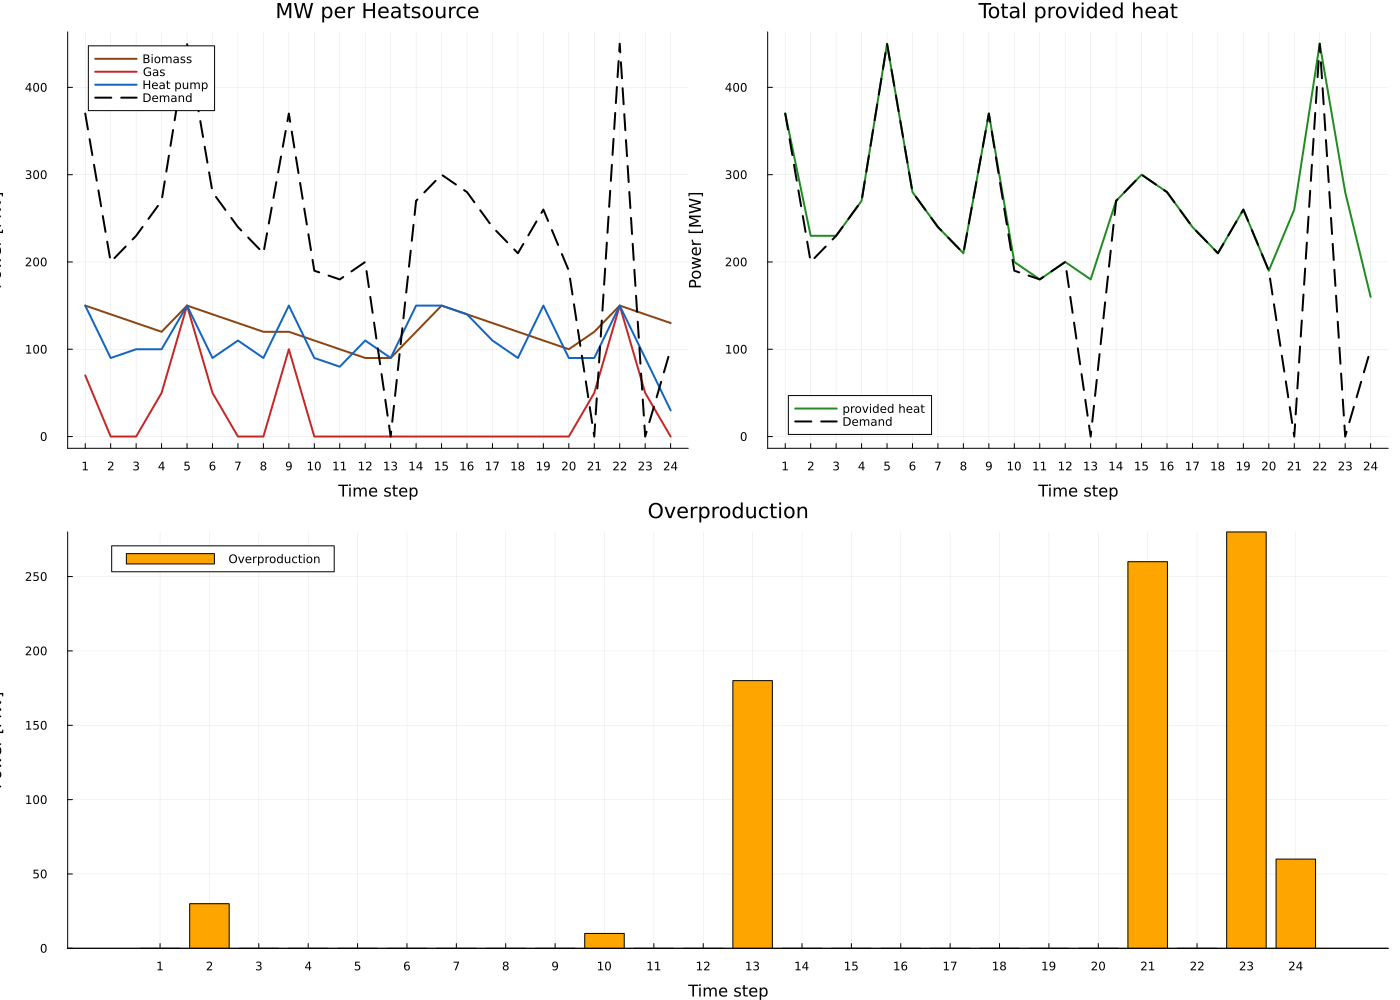

In [4]:
# Biomass - forest green
# Gas - dark red
# Heat pump - blue

# 1. HEAT SOURCES
p = plot( 1:N, 
        [value.(x1[j,:]) for j in 1:3], 
        labels=["Biomass" "Gas" "Heat pump"], 
        color = ["#8B4513" "#C62828" "#1565C0"],
        xlabel="Time step", 
        ylabel="Power [MW]", 
        lw=2 , 
        title="MW per Heatsource",
        xticks=1:N,
        grid=true)
plot!(p, 1:N, 
        d, 
        label="Demand", 
        lw=2, 
        linestyle=:dash,
        color=:black )

# 2. TOTAL PROVIDED HEAT
x1_result = value.(x1)

total = zeros(N)
for i=1:M
    total = total .+ x1_result[i,:]
end

p_total = plot(1:N, total, label="provided heat", lw=2,
        title="Total provided heat",
        color="#228B22",
        xticks=1:N,
        grid=true )
plot!(p_total, 1:N, d,   label="Demand", lw=2, linestyle=:dash,color=:black)

xlabel!(p_total, "Time step")
ylabel!(p_total, "Power [MW]")

# 3. OVERPRODUCTION
overproduction = max.(total .- d, 0)
p_overproduction = bar(1:N,
    overproduction,
    label="Overproduction",
    color=:orange,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Overproduction",
    xticks=1:N,
    grid=true)

hline!(
    p_overproduction,
    [0],
    color=:black,
    lw=1,
    label="")

p_combined = plot( p,p_total,p_overproduction,
    layout=@layout([
        a b
        e
    ]),    
    size=(1400,1000))

display(p_combined)


## Thermal storage

**For Model 2:**

- Maximum storage capacity: **200 MWh**
- Initial storage level: **100 MWh**
- Final storage level must equal the initial storage level.
- Maximum charging power: **80 MW**
- Maximum discharging power: **80 MW**
- Charging efficiency: **90 %**
- Discharging efficiency: **90 %**
- No standing losses are considered. 
- Charging and discharging are continuously.
- Excess heat may be discarded if it cannot be used or stored.

In [14]:
# 2opt

#THERMAL STORAGE
E_maxCharge = 80        # MW
E_maxDischarge = 80     # MW   
E_max = 200             # Storage Capacity  - MWh
E_start = 100           # Start Capacity    - MWh   

eff_charge = 0.9        # Heat loss while charging        
eff_discharge = 0.9     # Heat loss while discharging
eff_storage = 1.        # Heat loss while storing       - no influence!


using GLPK, JuMP, Plots
model2 = Model(GLPK.Optimizer)

@variable(model2, x2[1:3,1:N] >= 0)

@variable(model2, E[1:N] >= 0)
@variable(model2, charge[1:N] >= 0)
@variable(model2, discharge[1:N] >= 0)
@variable(model2, excessHeat[1:N] >= 0)

# KOSTEN minimieren
@objective(model2, Min, sum( sum(x2[j,t]*c[j] for t=1:N) for j=1:M))
# CONSTRAINTS:
# kann maximalen Wirkungsgrad nicht übersteigen    -    je Heizquelle
@constraint(model2, [j=1:M,t=1:N], x2[j,t] <= m[j])
# DEMAND hast to be met     -    für alle Zeitpunkte i
# @constraint(model, [t=1:N],   sum( x2[j,t] for j=1:M) >= d[t]    )

# heating speed
@constraint(model2, [j=1:M, t=2:N],  x2[j,t] - x2[j,t-1] <= ramp_up[j])
@constraint(model2, [j=1:M, t=2:N],  x2[j,t-1] - x2[j,t] <= ramp_down[j])

# SPEICHER
@constraint(model2, [t=1:N], charge[t]    <= E_maxCharge)                                 # charging-speed
@constraint(model2, [t=1:N], discharge[t] <= E_maxDischarge)
@constraint(model2, [t=1:N], E[t]         <= E_max)                                       # storage-capazity
@constraint(model2, [t=1:N], sum( x2[i,t] for i=1:M) + discharge[t] == d[t] + charge[t] + excessHeat[t])      # heat-equality

@constraint(model2, [t=2:N], E[t] == eff_storage * E[t-1] + eff_charge * charge[t] - 1/eff_discharge * discharge[t])          # keep track of storage
@constraint(model2, E[1] == E_start + eff_charge * charge[1] - 1/eff_discharge * discharge[1])
@constraint(model2, E[N] == E_start)

optimize!(model2)

println("Solver status: ", termination_status(model2))
println("Solution status: ", primal_status(model2))
## Printing the solution
println("Objective value = ", objective_value(model2)) 

cost = 0

for j=1:M
    for i=1:N
        print( round(value(x2[j,i]),digits=1) ,"\t")
        cost += value(x2[j,i])*c[j]
    end
    println("")
end

println("Cost in €: ",round(cost,digits=2))
print(round.(value.(excessHeat),digits=2))

Solver status: OPTIMAL
Solution status: FEASIBLE_POINT
Objective value = 182735.53432517286
140.0	130.0	120.0	120.0	150.0	140.0	130.0	120.0	114.5	104.5	94.5	84.5	74.5	104.5	107.2	97.2	87.2	77.2	70.0	60.0	90.0	120.0	110.0	100.0	
0.0	0.0	0.0	0.0	70.0	0.0	0.0	0.0	25.5	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	100.0	0.0	0.0	
150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	150.0	90.0	30.0	90.0	150.0	150.0	150.0	150.0	150.0	148.8	90.0	150.0	90.0	31.1	
Cost in €: 182735.53
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 24.47, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 100.0, 0.0, 120.0, 0.0]

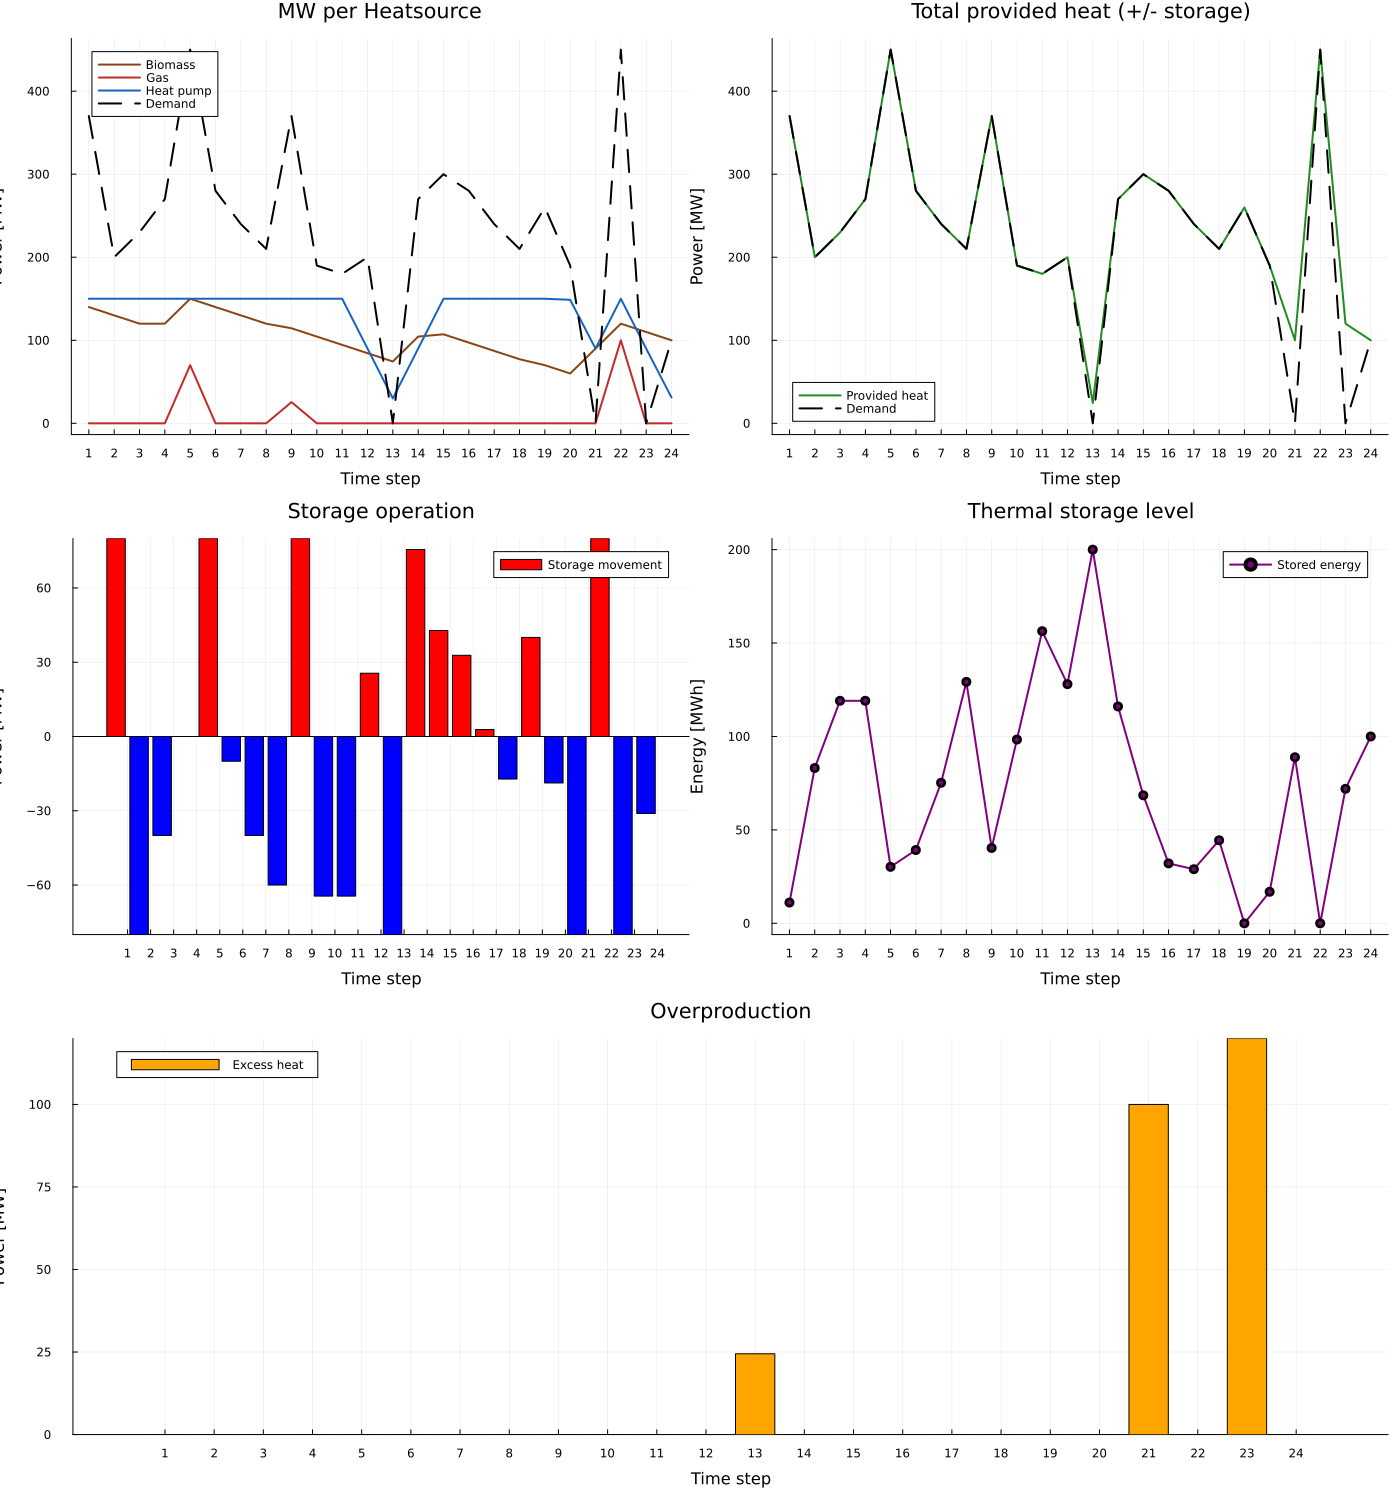

In [17]:
# PLOT RESULTS - MODEL WITH STORAGE
x2_result = value.(x2)

biomass = x2_result[1,:]
gas = x2_result[2,:]
heatpump = x2_result[3,:]

charge_result = value.(charge)
discharge_result = value.(discharge)
storage_level = value.(E)
storage_movement = discharge_result .- charge_result
# positive = storage gives heat
# negative = storage gets heat

# total heat provided to demand
total_generation = biomass .+ gas .+ heatpump
provided_heat = total_generation .+ storage_movement

# heat produced above actual demand
# excess_heat = max.(provided_heat .- d, 0)
excess_heat = value.(excessHeat)

# 1. HEAT SOURCES
p_sources = plot(1:N, 
    biomass,    label="Biomass",
    color="#8B4513",lw=2,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="MW per Heatsource",
    xticks=1:N,
    grid=true)
plot!(p_sources,1:N,
    gas,        label="Gas",
    color="#C62828",lw=2)
plot!(p_sources,1:N,
    heatpump,   label="Heat pump",
    color="#1565C0",lw=2)
plot!(p_sources,1:N,
    d,          label="Demand",
    color=:black,lw=2,linestyle=:dash)

# 2. TOTAL PROVIDED HEAT (with storage)
p_total = plot(1:N,
    provided_heat,  label="Provided heat",
    color="#228B22",lw=2,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Total provided heat (+/- storage)",
    xticks=1:N,
    grid=true)
plot!(p_total,1:N,
    d,          label="Demand",
    color=:black,lw=2,linestyle=:dash)

# 3. STORAGE MOVEMENT
movement_time = (1:N) .- 0.5
bar_colors = [storage_movement[i] >= 0 ? :red : :blue     for i in 1:length(storage_movement)]
# storage_movement[1] = 0

p_movement = bar(
    movement_time,
    storage_movement,
    label="Storage movement",
    color=bar_colors,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Storage operation",
    xticks=1:N,
    grid=true)

hline!(p_movement,[0],color=:black,lw=1,label="")

# 4. STORAGE LEVEL
p_storage = plot(1:N,
    storage_level,
    label="Stored energy",
    color=:purple,lw=2,
    marker=:circle,
    xlabel="Time step",
    ylabel="Energy [MWh]",
    title="Thermal storage level",
    xticks=1:N,
    grid=true)

# 5. EXCESS HEAT
p_excess = bar(1:N,
    excess_heat,
    label="Excess heat",color=:orange,
    xlabel="Time step",
    ylabel="Power [MW]",
    title="Overproduction",
    xticks=1:N,
    grid=true)

# COMBINED PLOT
p_combined = plot(
    p_sources, p_total, p_movement, p_storage, p_excess,
    layout=@layout([
        a b
        c d
        e
    ]),
    size=(1400,1500))

display(p_combined)

In [ ]:
# draufgaben:
# alpha = 1.0; beta = 0.0   # only cost
# # alpha = 0.5; beta = 0.5   # balanced
# # alpha = 0.2; beta = 0.8   # CO2-focused
# s = [30, 40, 200]        # SUSTAINABILITY    - kg_CO2/MWh



1